In [1]:
import re
import numpy as np
import pandas as pd
import h5py
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy.interpolate import griddata

In [223]:
folder='Site_1_hourly'
#folder='../Half_space_model/1yr_and_flux'

In [224]:
# Path to the .xmf file
file_path = folder+'/ats_vis_data.VisIt.xmf'

# Read the file content
with open(file_path, 'r') as file:
    content = file.read()

# Regular expression to match numbers between 'h5' and 'xmf'
pattern = r"h5\.(\d+)\.xmf"
matches = re.findall(pattern, content)

# Convert matches to integers
numbers = [int(match) for match in matches]

In [225]:
loc=pd.read_csv('data/Site_1_mesh_long.csv').iloc[:,[0,2]]
for i in range(len(numbers)):
    fin=loc.copy()
    temp=loc.copy()
    df=h5py.File(folder+'/ats_vis_data.h5', 'r')
    fin['porosity']=df['base_porosity'][str(numbers[i])]
    fin['U']=df['darcy_velocity.x'][str(numbers[i])]
    fin['W']=df['darcy_velocity.z'][str(numbers[i])]
    #fin['k']=df['permeability'][str(numbers[i])]
    fin['sat']=df['saturation_liquid'][str(numbers[i])]
    fin['time']=i
    temp['h']=df['pressure'][str(numbers[i])]
    if i==0:
        out=fin.copy()
        pressure=temp.copy()
        continue
    out=pd.concat([out,fin])
    pressure=pd.concat([pressure,temp])
    #break

In [226]:
#Assign homogeneous resistivity from field data
df=out.copy()
df['cond']=0
df['cond'][df["porosity"]>=0.4]=1/800# 40 original used
df['cond'][df["porosity"]<0.4]=1/200

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\2786395265.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['cond'][df["porosity"]>=0.4]=1/800# 40 original used
C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\2786395265.p

In [227]:
df1=df.iloc[:,[0,1,6,3,4,2,5,7]]
df1.columns = ['X', 'Z', 't', 'U','W', 'Por','sat','cond']
df1["Perm"]=0
df1['Perm'][df1["Por"]>=0.1]=6.734728e-14# 40 original used
df1['Perm'][df1["Por"]<0.1]=1.58e-12

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\324798618.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Perm"]=0
C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\324798618.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = va

In [228]:
df1.columns = ['X', 'Z', 't', 'U','W', 'Por','sat','cond','Perm']

In [229]:
df1['m']=1.5

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\4240784304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m']=1.5


In [230]:
df1['Qv']=0

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\3439745110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=0


In [231]:
pressure.h=pressure.h-101325
n_vg=1.283647
m_vg=(n_vg-1)/n_vg #Soldi et al, 2019
alpha=4.9e-05
pressure['sat']=0
pressure['sat']=-0.1+(1+abs(alpha*pressure['h'])**n_vg)**-m_vg
pressure['sat'][pressure['h']>0]=1

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\3124416783.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pressure['sat'][pressure['h']>0]=1


In [232]:
rel_perm=pressure['sat']**0.5*(1-(1-pressure['sat']**(1/m_vg))**m_vg)**2 #Soldi et al, 2019

In [233]:
#Calculating Qv from REV method
e0 = 1.602e-19   # Elementary charge (C)   
C0=200*1.3e-5 # fluid conc. from 0.02 S/m using eqn from Griffin and Jurinak
E=80.1*8.854e-12 # F/m
kB=1.381e-23
T=273.15+20
tau=df1["Por"]**(1-df1['m'])
phi=df1["Por"]
k=df1['Perm']
zeta=-0.00643+0.02085*np.log10(C0)
df1['Qv']=(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*pressure['sat']/rel_perm #Soldi et al, 2019

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\3717256916.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*pressure['sat']/rel_perm #Soldi et al, 2019


In [234]:
#plt.plot(df1[(df1['X']==107.75)&(df1['Z']==240.24443)]['Qv'].values)
#plt.plot(df1[(df1['X']==4.25)&(df1['Z']==241.34628)]['Qv'].values)
#plt.ylim(0,200)

In [235]:
#df1[(df1['X']==107.75)&(df1['Z']>240)]#259.79225

In [236]:
df1['Qv']=40/df1['sat']

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\235198631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=40/df1['sat']


In [237]:
df1.to_csv(folder+'/data_set_edit_hourly.txt',index=False)

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

In [261]:
year = 2024
month = 1
day = 1
number_of_days = 580
dates = pd.date_range(f'{year}-{month}-{day}', periods=int(number_of_days), freq="1d")


In [262]:
df1_1=pd.read_csv('C:/Users/m10921371/OneDrive - Colorado School of Mines/WADE_SFA/Field Data/NBO site/March 2025/SP/TN_Forest_1_TN_Forest_1.dat',skiprows=1).iloc[2:,:]
df1_1['TIMESTAMP']=pd.to_datetime(df1_1['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
df1_2=pd.read_csv('C:/Users/m10921371/OneDrive - Colorado School of Mines/WADE_SFA/Field Data/NBO site/July 2025/SP/TN_Forest_01_TN_Forest_1.dat',skiprows=1).iloc[2:,:]
df1_2['TIMESTAMP']=pd.to_datetime(df1_2['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
#df2_1=pd.read_csv('NBO site/March 2025/SP/TN_Forest_2_TN_Forest_02_SP.dat',skiprows=1).iloc[2:,:]
#df2_2=pd.read_csv('NBO site/July 2025/SP/TN_Forest_02_TN_Forest_02_SP.dat',skiprows=1).iloc[2:,:]
#df2_1['TIMESTAMP']=pd.to_datetime(df2_1['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
#df2_2['TIMESTAMP']=pd.to_datetime(df2_2['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
df1=pd.concat((df1_1,df1_2))

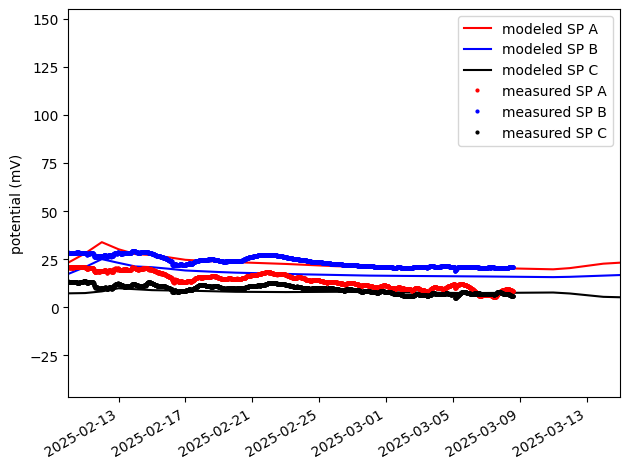

In [276]:
res=pd.read_csv('Site_1_hourly/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:234]
#plt.plot(dates[333:565],(res.iloc[98,2:]-res.iloc[217,2:]).values*1000, 'r', label="modeled SP A")
#
#plt.plot(dates[333:565],(res.iloc[104,2:]-res.iloc[217,2:]).values*1000, 'b', label="modeled SP B")
#
#plt.plot(dates[333:565],(res.iloc[16,2:]-res.iloc[217,2:]).values*1000, 'k', label="modeled SP C")
plt.plot(dates[333:565],(res.iloc[988,2:]-res.iloc[7714,2:]).values*1000, 'r', label="modeled SP A")
plt.plot(dates[333:565],(res.iloc[2732,2:]-res.iloc[7714,2:]).values*1000, 'b', label="modeled SP B")
plt.plot(dates[333:565],(res.iloc[6917,2:]-res.iloc[7714,2:]).values*1000, 'k', label="modeled SP C")
plt.plot(df1['TIMESTAMP'],pd.to_numeric(df1['SEVolt(1)'], errors='coerce')-pd.to_numeric(df1['SEVolt(5)'], errors='coerce'),'ro',markersize=2,label='measured SP A')
plt.plot(df1['TIMESTAMP'],pd.to_numeric(df1['SEVolt(2)'], errors='coerce')-pd.to_numeric(df1['SEVolt(5)'], errors='coerce'),'bo',markersize=2,label='measured SP B')
plt.plot(df1['TIMESTAMP'],pd.to_numeric(df1['SEVolt(3)'], errors='coerce')-pd.to_numeric(df1['SEVolt(5)'], errors='coerce'),'ko',markersize=2,label='measured SP C')

#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
plt.ylabel('potential (mV)')
plt.legend()
plt.xlim(datetime.strptime('2025/02/10 00:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2025/03/15 00:00:00', '%Y/%m/%d %H:%M:%S'))
#plt.ylim(-20,50)
fig = plt.gcf()
fig.autofmt_xdate()
fig.tight_layout()

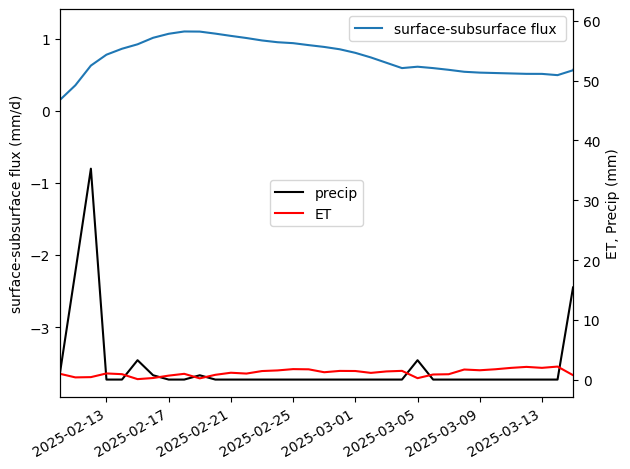

In [180]:
fig,ax=plt.subplots()
ax2=ax.twinx()
ax.plot(dates[333:565],temp["surface-surface_subsurface_flux"]*1000, label="surface-subsurface flux ")
ax2.plot(dates[333:565],temp2['rain precipitation [m d^-1]']*1000,"k", label="precip")
ax2.plot(dates[333:565],temp2['evapotranspiration [m d^-1]']*1000,"r", label="ET")
ax.set_ylabel("surface-subsurface flux (mm/d)")
ax2.set_ylabel("ET, Precip (mm)")
ax.set_xlim(datetime.strptime('2025/02/10 00:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2025/03/15 00:00:00', '%Y/%m/%d %H:%M:%S'))
ax.legend()
ax2.legend(loc="center")
fig.autofmt_xdate()
fig.tight_layout()

In [79]:
#res=pd.read_csv('Site_1_hourly/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:234]
#res[(res['%']>103.8)&(res['%']<104.2)&(res['x']>241)]#1395,1548,2540,2892
#res.loc[[98,104,16,217]]
res.loc[[1395,1548,2540,2892]]

,%,x,y,V,(V),@,t=0,V.1,(V).1,@.1,...,(V).55,@.55,t=55,V.56,(V).56,@.56,t=56,V.57,(V).57,@.57
1395,103.920327,241.219019,1.072605,1.084567,0.634825,0.193056,-0.058714,-0.035377,-0.017445,-0.009345,...,0.544437,0.204468,0.126489,0.088535,0.069837,0.068018,0.053918,0.037209,0.024981,0.011060
1548,103.022989,241.388454,1.057537,1.052290,0.854037,0.321540,-0.004046,-0.038360,-0.018655,-0.010149,...,0.543145,0.209168,0.130719,0.092218,0.073126,0.073421,0.064454,0.044963,0.032529,0.014977
2540,100.892416,241.427087,1.048062,0.988110,0.802923,0.292568,0.098348,-0.034027,-0.022326,-0.012126,...,0.548018,0.209342,0.131200,0.094877,0.075912,0.068967,0.059682,0.040008,0.028139,0.013489
2892,98.716039,240.826266,1.019099,0.709346,-0.025805,-0.017953,-0.046450,-0.030383,-0.023231,-0.016105,...,0.550159,0.199347,0.121473,0.085728,0.068382,0.056435,0.040138,0.024298,0.012911,0.003708


In [275]:
res.loc[[988,2732,6917,7714]]#

,%,x,y,V,(V),@,t=0,V.1,(V).1,@.1,...,(V).55,@.55,t=55,V.56,(V).56,@.56,t=56,V.57,(V).57,@.57
988,103.911912,241.448067,0.568450,0.458718,0.424422,0.407840,0.394467,0.392922,0.392652,0.391957,...,0.381277,0.382513,0.383643,0.383921,0.384765,0.387195,0.389209,0.388227,0.387244,0.393298
2732,103.014508,241.361197,0.541771,0.462035,0.424300,0.406576,0.395044,0.391872,0.390547,0.389221,...,0.376370,0.378615,0.380944,0.381241,0.381962,0.384439,0.386519,0.385734,0.384948,0.390867
6917,100.846554,241.522149,0.477010,0.467318,0.422813,0.403123,0.393349,0.389751,0.386840,0.384430,...,0.366230,0.369686,0.373560,0.374241,0.374999,0.377215,0.379094,0.378552,0.378010,0.384054
7714,98.766193,240.824508,0.422606,0.466872,0.414558,0.394247,0.385295,0.382591,0.380492,0.378469,...,0.360327,0.362586,0.365583,0.366432,0.367368,0.369204,0.370754,0.370244,0.369734,0.376357


### Site 2

In [242]:
folder='Site_2_hourly'
#folder='Site_2_hourly'
#folder='../Half_space_model/1yr_and_flux'

In [243]:
# Path to the .xmf file
file_path = folder+'/ats_vis_data.VisIt.xmf'

# Read the file content
with open(file_path, 'r') as file:
    content = file.read()

# Regular expression to match numbers between 'h5' and 'xmf'
pattern = r"h5\.(\d+)\.xmf"
matches = re.findall(pattern, content)

# Convert matches to integers
numbers = [int(match) for match in matches]

In [244]:
loc=pd.read_csv('data/Site_2_mesh_long.csv').iloc[:,[0,2]]
for i in range(len(numbers)):
    fin=loc.copy()
    temp=loc.copy()
    df=h5py.File(folder+'/ats_vis_data.h5', 'r')
    fin['porosity']=df['base_porosity'][str(numbers[i])]
    fin['U']=df['darcy_velocity.x'][str(numbers[i])]
    fin['W']=df['darcy_velocity.z'][str(numbers[i])]
    #fin['k']=df['permeability'][str(numbers[i])]
    fin['sat']=df['saturation_liquid'][str(numbers[i])]
    fin['time']=i
    temp['h']=df['pressure'][str(numbers[i])]
    if i==0:
        out=fin.copy()
        pressure=temp.copy()
        continue
    out=pd.concat([out,fin])
    pressure=pd.concat([pressure,temp])
    #break

In [245]:
#Assign homogeneous resistivity from field data
df=out.copy()
df['cond']=0
df['cond'][df["porosity"]>=0.4]=1/1600# 800 original used
df['cond'][df["porosity"]<0.4]=1/200

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\659417076.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['cond'][df["porosity"]>=0.4]=1/1600# 800 original used
C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\659417076.p

In [246]:
df1=df.iloc[:,[0,1,6,3,4,2,5,7]]
df1.columns = ['X', 'Z', 't', 'U','W', 'Por','sat','cond']
df1["Perm"]=0
df1['Perm'][df1["Por"]>=0.1]=6.734728e-14# 40 original used
df1['Perm'][df1["Por"]<0.1]=1.58e-12

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\324798618.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Perm"]=0
C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\324798618.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = va

In [247]:
df1.columns = ['X', 'Z', 't', 'U','W', 'Por','sat','cond','Perm']

In [248]:
df1['m']=1.5

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\4240784304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m']=1.5


In [249]:
df1['Qv']=0

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\3439745110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=0


In [250]:
pressure.h=pressure.h-101325
n_vg=1.283647
m_vg=(n_vg-1)/n_vg #Soldi et al, 2019
alpha=4.9e-05
pressure['sat']=0
pressure['sat']=-0.1+(1+abs(alpha*pressure['h'])**n_vg)**-m_vg
pressure['sat'][pressure['h']>0]=1

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\3124416783.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pressure['sat'][pressure['h']>0]=1


In [251]:
rel_perm=pressure['sat']**0.5*(1-(1-pressure['sat']**(1/m_vg))**m_vg)**2 #Soldi et al, 2019

In [252]:
#Calculating Qv from REV method
e0 = 1.602e-19   # Elementary charge (C)   
C0=200*1.3e-5 # fluid conc. from 0.02 S/m using eqn from Griffin and Jurinak
E=80.1*8.854e-12 # F/m
kB=1.381e-23
T=273.15+20
tau=df1["Por"]**(1-df1['m'])
phi=df1["Por"]
k=df1['Perm']
zeta=-0.00643+0.02085*np.log10(C0)
df1['Qv']=0.3*(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*pressure['sat']/rel_perm #Soldi et al, 2019

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\2537647024.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=0.3*(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*pressure['sat']/rel_perm #Soldi et al, 2019


In [253]:
df1['Qv']=6/df1['sat']

C:\Users\m10921371\AppData\Local\Temp\ipykernel_137480\3182448362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=6/df1['sat']


In [254]:
#plt.plot(df1[(df1['X']==4.75)&(df1['Z']==239.23906)]['Qv'].values)

In [255]:
#df1[(df1['X']==4.75)&(df1['Z']>238)]#259.79225

In [256]:
df1.to_csv(folder+'/data_set_edit_hourly_cond.txt',index=False)

Text(0, 0.5, 'modeled potential (mV)')

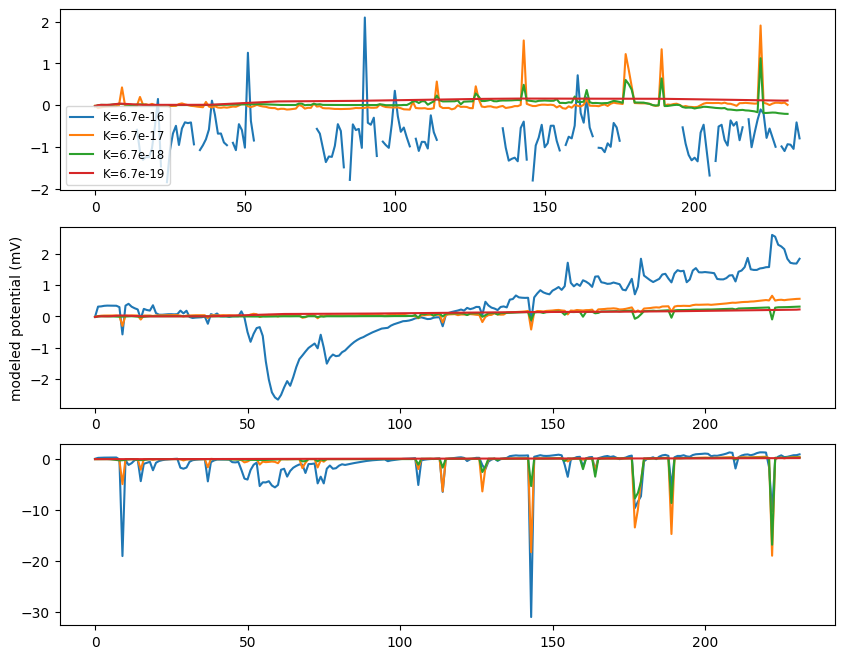

In [94]:
fig,ax=plt.subplots(3,1, figsize=(10,8))
res6=pd.read_csv('Site_2_profile_hourly_Step6/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
#ax[0].plot((res6.iloc[1902,2:]-res6.iloc[1647,2:]).values*1000, label = "K=6.7e-12")
#ax[1].plot((res6.iloc[159,2:]-res6.iloc[1647,2:]).values*1000)
#ax[2].plot((res6.iloc[140,2:]-res6.iloc[1647,2:]).values*1000)

res1=pd.read_csv('Site_2_profile_hourly_Step1/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
#ax[0].plot((res1.iloc[1902,2:]-res1.iloc[1647,2:]).values*1000, label = "K=6.7e-15")
#ax[1].plot((res1.iloc[159,2:]-res1.iloc[1647,2:]).values*1000)
#ax[2].plot((res1.iloc[140,2:]-res1.iloc[1647,2:]).values*1000)

res3=pd.read_csv('Site_2_profile_hourly_Step2/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res3.iloc[1902,2:]-res3.iloc[1647,85:]).values*1000, label = "K=6.7e-16")
ax[1].plot((res3.iloc[159,2:]-res3.iloc[1647,2:]).values*1000)
ax[2].plot((res3.iloc[140,2:]-res3.iloc[1647,2:]).values*1000)

res2=pd.read_csv('Site_2_profile_hourly_Step3/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res2.iloc[1902,2:]-res2.iloc[1647,2:]).values*1000, label = "K=6.7e-17")
ax[1].plot((res2.iloc[159,2:]-res2.iloc[1647,2:]).values*1000)
ax[2].plot((res2.iloc[140,2:]-res2.iloc[1647,2:]).values*1000)
res4=pd.read_csv('Site_2_profile_hourly_Step4/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res4.iloc[1902,2:]-res4.iloc[1647,2:]).values*1000, label = "K=6.7e-18")
ax[1].plot((res4.iloc[159,2:]-res4.iloc[1647,2:]).values*1000)
ax[2].plot((res4.iloc[140,2:]-res4.iloc[1647,2:]).values*1000)

res5=pd.read_csv('Site_2_profile_hourly_Step5/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
ax[0].plot((res5.iloc[1902,2:]-res5.iloc[1647,2:]).values*1000, label = "K=6.7e-19")
ax[1].plot((res5.iloc[159,2:]-res5.iloc[1647,2:]).values*1000)
ax[2].plot((res5.iloc[140,2:]-res5.iloc[1647,2:]).values*1000)

ax[0].legend(loc="lower left", fontsize='small')
#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[1].set_ylabel('modeled potential (mV)')
#plt.xlim(-30,30)

In [131]:
df2_1=pd.read_csv('C:/Users/m10921371/OneDrive - Colorado School of Mines/WADE_SFA/Field Data/NBO site/March 2025/SP/TN_Forest_2_TN_Forest_02_SP.dat',skiprows=1).iloc[2:,:]
df2_2=pd.read_csv('C:/Users/m10921371/OneDrive - Colorado School of Mines/WADE_SFA/Field Data/NBO site/July 2025/SP/TN_Forest_02_TN_Forest_02_SP.dat',skiprows=1).iloc[2:,:]
df2_1['TIMESTAMP']=pd.to_datetime(df2_1['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
df2_2['TIMESTAMP']=pd.to_datetime(df2_2['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
df2=pd.concat((df2_1,df2_2))

(20129.0, 20302.0)

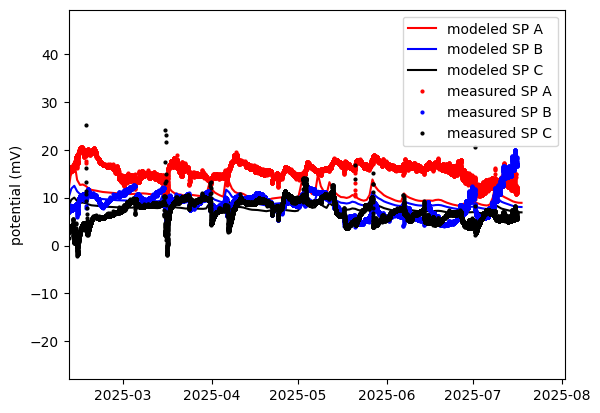

In [204]:
res=pd.read_csv('Site_2_hourly/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:234]
plt.plot(dates[333:565],(res.iloc[1516,2:]-res.iloc[1631,2:]).values*1000, 'r', label="modeled SP A")

plt.plot(dates[333:565],(res.iloc[980,2:]-res.iloc[1631,2:]).values*1000, 'b', label="modeled SP B")

plt.plot(dates[333:565],(res.iloc[1327,2:]-res.iloc[1631,2:]).values*1000, 'k', label="modeled SP C")
plt.plot(df2['TIMESTAMP'],pd.to_numeric(df2['SEVolt(1)'], errors='coerce')-pd.to_numeric(df2['SEVolt(5)'], errors='coerce'),'ro',markersize=2,label='measured SP A')
plt.plot(df2['TIMESTAMP'],pd.to_numeric(df2['SEVolt(2)'], errors='coerce')-pd.to_numeric(df2['SEVolt(5)'], errors='coerce'),'bo',markersize=2,label='measured SP B')
plt.plot(df2['TIMESTAMP'],pd.to_numeric(df2['SEVolt(3)'], errors='coerce')-pd.to_numeric(df2['SEVolt(5)'], errors='coerce'),'ko',markersize=2,label='measured SP C')
#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
plt.ylabel('potential (mV)')
plt.legend()
#plt.xlim(datetime.strptime('2025/04/20 00:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2025/05/01 00:00:00', '%Y/%m/%d %H:%M:%S'))
plt.xlim(datetime.strptime('2025/02/10 00:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2025/08/02 00:00:00', '%Y/%m/%d %H:%M:%S'))
#plt.ylim(-10,30)

(20129.0, 20302.0)

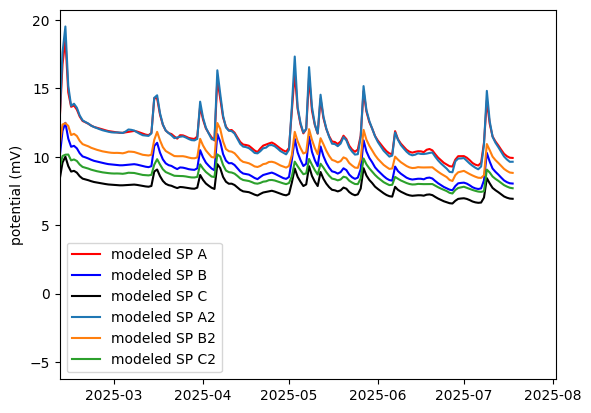

In [259]:
res=pd.read_csv('Site_2_hourly/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:234]
res2=pd.read_csv('Site_2_hourly/result_cond.txt',skiprows=8,delimiter ='\s+').iloc[:,:234]
plt.plot(dates[333:565],(res.iloc[1516,2:]-res.iloc[1631,2:]).values*1000+1, 'r', label="modeled SP A")
plt.plot(dates[333:565],(res.iloc[980,2:]-res.iloc[1631,2:]).values*1000, 'b', label="modeled SP B")
plt.plot(dates[333:565],(res.iloc[1327,2:]-res.iloc[1631,2:]).values*1000, 'k', label="modeled SP C")

plt.plot(dates[333:565],(res2.iloc[1516,2:]-res2.iloc[1631,2:]).values*1000, label="modeled SP A2")
plt.plot(dates[333:565],(res2.iloc[980,2:]-res2.iloc[1631,2:]).values*1000, label="modeled SP B2")
plt.plot(dates[333:565],(res2.iloc[1327,2:]-res2.iloc[1631,2:]).values*1000, label="modeled SP C2")

#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
plt.ylabel('potential (mV)')
plt.legend()
#plt.xlim(datetime.strptime('2025/04/20 00:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2025/05/01 00:00:00', '%Y/%m/%d %H:%M:%S'))
plt.xlim(datetime.strptime('2025/02/10 00:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2025/08/02 00:00:00', '%Y/%m/%d %H:%M:%S'))
#plt.ylim(-10,30)

(20129.0, 20302.0)

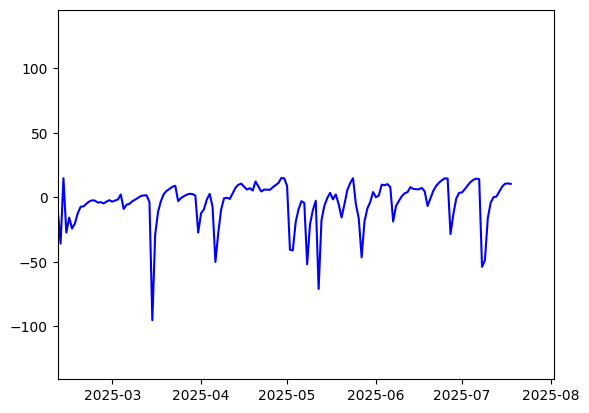

In [150]:
plt.plot(dates[333:565],(res.iloc[159,2:]-res.iloc[1647,2:]).values*1000, 'b', label="modeled SP B")
plt.xlim(datetime.strptime('2025/02/10 00:00:00', '%Y/%m/%d %H:%M:%S'),datetime.strptime('2025/08/02 00:00:00', '%Y/%m/%d %H:%M:%S'))

In [147]:
max((res.iloc[159,2:]-res.iloc[1647,2:]).values*1000)

42.9906056670374

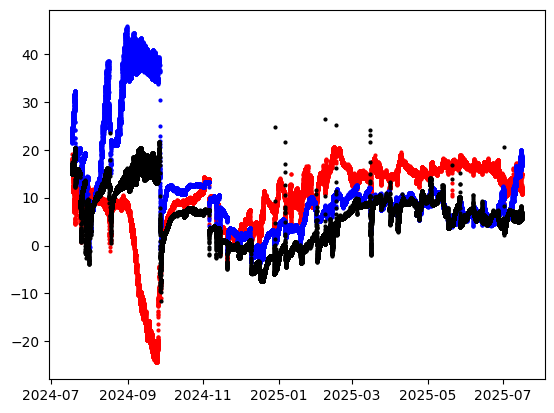

In [106]:
plt.plot(df2['TIMESTAMP'],pd.to_numeric(df2['SEVolt(1)'], errors='coerce')-pd.to_numeric(df2['SEVolt(5)'], errors='coerce'),'ro',markersize=2,label='measured SP A')
plt.plot(df2['TIMESTAMP'],pd.to_numeric(df2['SEVolt(2)'], errors='coerce')-pd.to_numeric(df2['SEVolt(5)'], errors='coerce'),'bo',markersize=2,label='measured SP B')
plt.plot(df2['TIMESTAMP'],pd.to_numeric(df2['SEVolt(3)'], errors='coerce')-pd.to_numeric(df2['SEVolt(5)'], errors='coerce'),'ko',markersize=2,label='measured SP C')

In [102]:
res.loc[[1902,159,140,1647]]

,%,x,y,V,(V),@,t=0,V.1,(V).1,@.1,...,(V).55,@.55,t=55,V.56,(V).56,@.56,t=56,V.57,(V).57,@.57
1902,0.000000,238.623493,0.107364,-0.378259,-0.351996,-0.348500,-0.350024,-0.317301,-0.059360,-0.347464,...,0.027868,-0.252284,-0.292548,-0.302000,-0.305184,-0.318771,-0.325737,-0.329423,-0.331812,-0.313490
159,2.982173,238.949391,-0.002471,0.041956,0.021404,0.007551,-0.001955,-0.008357,-0.023722,-0.013609,...,-0.088544,-0.041460,-0.013989,0.000415,0.002021,0.012466,0.023603,0.030200,0.032121,0.030597
140,4.674891,239.262316,0.021883,0.047385,0.036242,0.027219,0.020174,0.015186,0.006852,0.009938,...,-0.198593,-0.051092,-0.010653,0.009479,0.004835,0.029239,0.045453,0.055218,0.058145,0.059226
1647,9.600000,239.001489,0.001892,-0.001361,-0.000968,-0.000809,-0.000664,-0.000468,-0.000220,-0.000428,...,0.074200,0.014142,0.001095,-0.000420,-0.000011,-0.001970,-0.002964,-0.003368,-0.003562,-0.003803


In [127]:
res=pd.read_csv('Site_2_hourly/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:234]
res.loc[[1516,980,1327,1631]]

,%,x,y,V,(V),@,t=0,V.1,(V).1,@.1,...,(V).55,@.55,t=55,V.56,(V).56,@.56,t=56,V.57,(V).57,@.57
1516,0.000000,238.615005,0.349527,-0.129555,-0.078061,-0.056255,-0.026288,-0.016857,-0.009858,-0.003896,...,0.061767,0.029241,0.019218,0.015991,0.013871,0.013374,0.012054,0.010925,0.010205,0.009666
980,2.902920,238.983296,0.027558,0.215433,0.146005,0.122514,0.123787,0.105547,0.084516,0.073442,...,-0.061390,-0.002348,0.010347,0.015637,0.016104,0.021822,0.026946,0.029924,0.030463,0.029545
1327,4.646552,239.060657,0.067233,0.170398,0.137449,0.118809,0.126541,0.116914,0.101781,0.092422,...,-0.055491,-0.006100,0.007102,0.013143,0.014376,0.019990,0.025457,0.028872,0.029885,0.029495
1631,9.619781,239.106778,0.052568,0.008355,0.038783,0.109010,0.132007,0.127674,0.117308,0.112450,...,-0.037844,-0.010064,0.002351,0.008206,0.012108,0.016054,0.021301,0.024638,0.026448,0.026872


In [126]:
#res[(res['%']>=9.5)&(res['%']<9.7)&(res['x']>238.8)]#1516,980,1327,1631